In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
orders = pd.read_csv("data/orders.csv")
customers = pd.read_csv("data/customers.csv")
restaurants = pd.read_csv("data/restaurants.csv")
coupons = pd.read_csv("data/coupons.csv")
coupon_offers = pd.read_csv("data/coupon_offers.csv")

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Restaurants:", restaurants.shape)
print("Coupons:", coupons.shape)
print("Coupon offers:", coupon_offers.shape)

Orders: (2400, 14)
Customers: (300, 4)
Restaurants: (30, 5)
Coupons: (8, 8)
Coupon offers: (1200, 5)


In [6]:
print("Dataset shape:", orders.shape)
print("\nColumn names:")
print(orders.columns.tolist())

orders.head()

Dataset shape: (2400, 14)

Column names:
['order_id', 'customer_id', 'restaurant_id', 'order_date', 'gross_order_value', 'coupon_id', 'discount_amount', 'net_order_value', 'delivery_fee', 'food_cost', 'order_status', 'payment_method', 'estimated_zomato_revenue', 'estimated_profit']


,order_id,customer_id,restaurant_id,order_date,gross_order_value,coupon_id,discount_amount,net_order_value,delivery_fee,food_cost,order_status,payment_method,estimated_zomato_revenue,estimated_profit
0,1.0,3,9,2025-01-03,259.79,NaN,0.0,259.79,45.0,161.18,Delivered,Card,91.76,59.76
1,2.0,212,7,2025-02-02,520.16,NaN,0.0,520.16,0.0,330.57,Delivered,Cash,104.03,72.03
2,3.0,79,19,2025-01-03,232.63,NaN,0.0,232.63,55.0,131.71,Delivered,Cash,106.18,74.18
3,4.0,3,3,2025-04-24,402.02,NaN,0.0,402.02,0.0,223.11,Delivered,Card,100.51,68.51
4,5.0,148,20,2025-12-10,249.34,NaN,0.0,249.34,45.0,145.35,Delivered,Wallet,94.87,62.87


In [7]:
orders.info()

print("\nMissing values:")
print(orders.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  2400 non-null   float64
 1   customer_id               2400 non-null   int64  
 2   restaurant_id             2400 non-null   int64  
 3   order_date                2400 non-null   object 
 4   gross_order_value         2400 non-null   float64
 5   coupon_id                 95 non-null     float64
 6   discount_amount           2400 non-null   float64
 7   net_order_value           2400 non-null   float64
 8   delivery_fee              2400 non-null   float64
 9   food_cost                 2400 non-null   float64
 10  order_status              2400 non-null   object 
 11  payment_method            2400 non-null   object 
 12  estimated_zomato_revenue  2400 non-null   float64
 13  estimated_profit          2400 non-null   float64
dtypes: float

In [8]:
# Convert order_date from text to datetime
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

# Remove accidental duplicate rows
orders = orders.drop_duplicates().copy()

# Clean text columns
orders["order_status"] = orders["order_status"].str.strip().str.title()
orders["payment_method"] = orders["payment_method"].str.strip().str.title()

print("Rows after removing duplicates:", len(orders))
print("Invalid dates:", orders["order_date"].isnull().sum())
print("\nOrder statuses:")
print(orders["order_status"].value_counts())

Rows after removing duplicates: 2400
Invalid dates: 0

Order statuses:
order_status
Delivered    2249
Cancelled     151
Name: count, dtype: int64


In [9]:
# Keep only completed orders for financial analysis
delivered_orders = orders[
    orders["order_status"] == "Delivered"
].copy()

# Classify coupon and non-coupon orders
delivered_orders["order_type"] = np.where(
    delivered_orders["coupon_id"].notna()
    & (delivered_orders["discount_amount"] > 0),
    "Coupon Order",
    "Non-Coupon Order"
)

# Create time-based columns
delivered_orders["order_month"] = (
    delivered_orders["order_date"].dt.to_period("M").astype(str)
)

delivered_orders["order_day"] = (
    delivered_orders["order_date"].dt.day_name()
)

delivered_orders["order_hour"] = (
    delivered_orders["order_date"].dt.hour
)

print("Delivered orders:", len(delivered_orders))
print("\nOrder types:")
print(delivered_orders["order_type"].value_counts())

Delivered orders: 2249

Order types:
order_type
Non-Coupon Order    2159
Coupon Order          90
Name: count, dtype: int64


In [10]:
total_orders = len(delivered_orders)
unique_customers = delivered_orders["customer_id"].nunique()
total_order_value = delivered_orders["gross_order_value"].sum()
average_order_value = delivered_orders["gross_order_value"].mean()
total_revenue = delivered_orders["estimated_zomato_revenue"].sum()
total_profit = delivered_orders["estimated_profit"].sum()

print(f"Delivered Orders: {total_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Total Order Value: ₹{total_order_value:,.2f}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")

Delivered Orders: 2,249
Unique Customers: 300
Total Order Value: ₹1,274,751.47
Average Order Value: ₹566.81
Total Revenue: ₹339,412.84
Total Profit: ₹255,943.47


In [11]:
coupon_comparison = (
    delivered_orders
    .groupby("order_type")
    .agg(
        total_orders=("order_id", "count"),
        average_order_value=("gross_order_value", "mean"),
        average_discount=("discount_amount", "mean"),
        total_revenue=("estimated_zomato_revenue", "sum"),
        average_profit=("estimated_profit", "mean"),
        total_profit=("estimated_profit", "sum")
    )
    .round(2)
    .reset_index()
)

coupon_comparison

,order_type,total_orders,average_order_value,average_discount,total_revenue,average_profit,total_profit
0,Coupon Order,90,769.38,127.79,17101.43,30.22,2720.06
1,Non-Coupon Order,2159,558.36,0.00,322311.41,117.29,253223.41


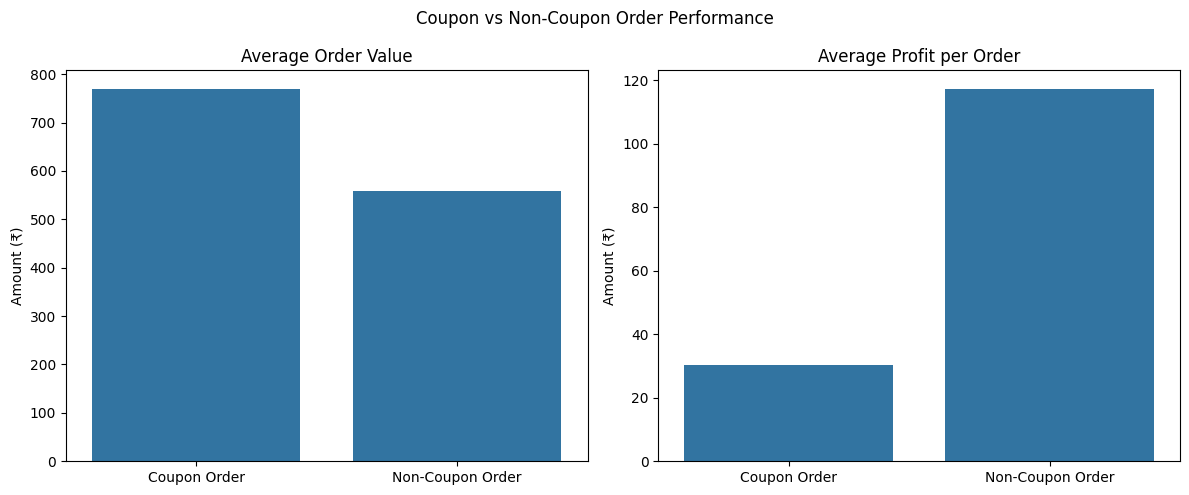

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=coupon_comparison,
    x="order_type",
    y="average_order_value",
    ax=axes[0]
)
axes[0].set_title("Average Order Value")
axes[0].set_xlabel("")
axes[0].set_ylabel("Amount (₹)")

sns.barplot(
    data=coupon_comparison,
    x="order_type",
    y="average_profit",
    ax=axes[1]
)
axes[1].set_title("Average Profit per Order")
axes[1].set_xlabel("")
axes[1].set_ylabel("Amount (₹)")

plt.suptitle("Coupon vs Non-Coupon Order Performance")
plt.tight_layout()
plt.show()

In [13]:
monthly_summary = (
    delivered_orders
    .groupby("order_month")
    .agg(
        total_orders=("order_id", "count"),
        total_revenue=("estimated_zomato_revenue", "sum"),
        total_profit=("estimated_profit", "sum"),
        total_discount=("discount_amount", "sum")
    )
    .reset_index()
)

monthly_summary

,order_month,total_orders,total_revenue,total_profit,total_discount
0,2025-01,203,28696.26,22080.26,120.00
1,2025-02,172,25079.84,19500.84,75.00
2,2025-03,181,27648.88,21404.87,452.01
3,2025-04,165,24112.17,18452.18,379.99
4,2025-05,199,31509.77,24447.63,694.14
5,2025-06,194,29568.42,22400.42,960.00
6,2025-07,190,30184.72,21667.09,2437.63
7,2025-08,181,27127.93,19846.90,1489.03
8,2025-09,209,31115.88,23637.88,790.00
9,2025-10,192,28746.98,21184.10,1418.88


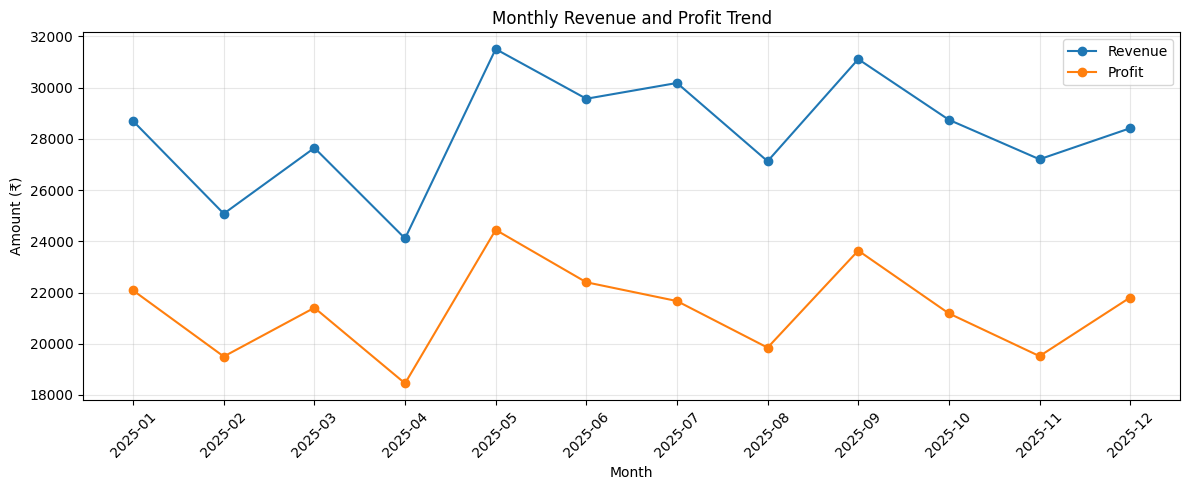

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary["order_month"],
    monthly_summary["total_revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    monthly_summary["order_month"],
    monthly_summary["total_profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Revenue and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
coupon_orders = delivered_orders[
    delivered_orders["order_type"] == "Coupon Order"
].merge(
    coupons[["coupon_id", "coupon_code"]],
    on="coupon_id",
    how="left"
)

coupon_performance = (
    coupon_orders
    .groupby("coupon_code")
    .agg(
        total_uses=("order_id", "count"),
        average_order_value=("gross_order_value", "mean"),
        average_discount=("discount_amount", "mean"),
        total_revenue=("estimated_zomato_revenue", "sum"),
        average_profit=("estimated_profit", "mean"),
        total_profit=("estimated_profit", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("average_profit", ascending=False)
)

coupon_performance

,coupon_code,total_uses,average_order_value,average_discount,total_revenue,average_profit,total_profit
4,REPEAT75,18,762.85,75.00,3499.37,87.41,1573.37
5,SAVE100,6,823.99,100.00,1218.97,71.16,426.97
3,PAYDAY25,8,1159.42,187.52,2205.43,56.16,449.30
2,FREEDLV,10,595.25,44.00,1241.42,48.14,481.42
6,WEEKEND20,17,654.69,109.38,2755.88,20.73,352.37
0,FESTIVE30,9,1051.82,240.35,2434.39,-1.86,-16.76
1,FLASH40,13,730.50,172.20,2386.23,-20.64,-268.35
7,WELCOME50,9,583.17,150.00,1359.74,-30.92,-278.26


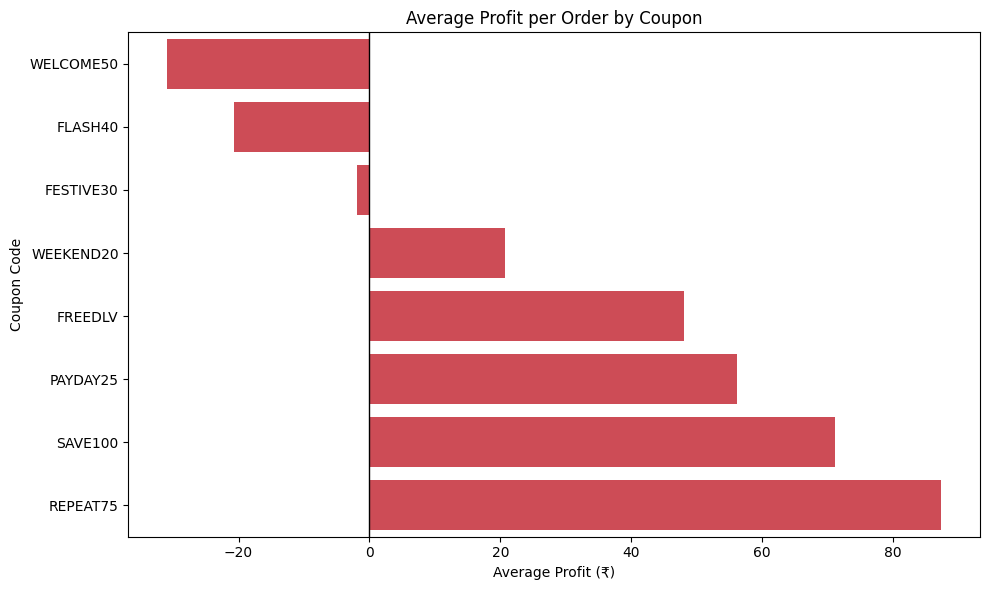

In [16]:
coupon_plot_data = coupon_performance.sort_values(
    "average_profit",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=coupon_plot_data,
    x="average_profit",
    y="coupon_code",
    color="#E23744"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Average Profit per Order by Coupon")
plt.xlabel("Average Profit (₹)")
plt.ylabel("Coupon Code")
plt.tight_layout()
plt.show()

In [17]:
coupon_offers["offer_date"] = pd.to_datetime(
    coupon_offers["offer_date"],
    errors="coerce"
)

coupon_offers = coupon_offers.drop_duplicates().copy()

print("Total offers:", len(coupon_offers))
print(
    "Unique customer-coupon pairs:",
    coupon_offers[
        ["customer_id", "coupon_id"]
    ].drop_duplicates().shape[0]
)
print("Invalid offer dates:", coupon_offers["offer_date"].isnull().sum())
print("\nOffers by channel:")
print(coupon_offers["channel"].value_counts())

Total offers: 1200
Unique customer-coupon pairs: 936
Invalid offer dates: 0

Offers by channel:
channel
Email               318
Homepage Banner     318
App Notification    289
SMS                 275
Name: count, dtype: int64


In [18]:
offer_analysis = coupon_offers.sort_values(
    ["customer_id", "coupon_id", "offer_date"]
).copy()

offer_analysis["next_offer_date"] = (
    offer_analysis
    .groupby(["customer_id", "coupon_id"])["offer_date"]
    .shift(-1)
)

coupon_delivered = delivered_orders[
    delivered_orders["coupon_id"].notna()
].copy()


def check_redemption(offer):
    window_end = offer["offer_date"] + pd.Timedelta(days=30)

    if pd.notna(offer["next_offer_date"]):
        window_end = min(window_end, offer["next_offer_date"])

    matching_orders = coupon_delivered[
        (coupon_delivered["customer_id"] == offer["customer_id"])
        & (coupon_delivered["coupon_id"] == offer["coupon_id"])
        & (coupon_delivered["order_date"] >= offer["offer_date"])
        & (coupon_delivered["order_date"] < window_end)
    ]

    return int(not matching_orders.empty)


offer_analysis["redeemed"] = offer_analysis.apply(
    check_redemption,
    axis=1
)

total_offers = len(offer_analysis)
redeemed_offers = offer_analysis["redeemed"].sum()
redemption_rate = 100 * redeemed_offers / total_offers

print("Total offers:", total_offers)
print("Redeemed offers:", redeemed_offers)
print(f"Redemption rate: {redemption_rate:.2f}%")

Total offers: 1200
Redeemed offers: 90
Redemption rate: 7.50%


In [19]:
channel_performance = (
    offer_analysis
    .groupby("channel")
    .agg(
        total_offers=("offer_id", "count"),
        redeemed_offers=("redeemed", "sum")
    )
    .reset_index()
)

channel_performance["redemption_rate_percent"] = (
    100
    * channel_performance["redeemed_offers"]
    / channel_performance["total_offers"]
).round(2)

channel_performance = channel_performance.sort_values(
    "redemption_rate_percent",
    ascending=False
)

channel_performance

,channel,total_offers,redeemed_offers,redemption_rate_percent
3,SMS,275,23,8.36
2,Homepage Banner,318,26,8.18
1,Email,318,22,6.92
0,App Notification,289,19,6.57


In [20]:
coupon_restaurant_data = coupon_orders.merge(
    restaurants,
    on="restaurant_id",
    how="left"
)

restaurant_performance = (
    coupon_restaurant_data
    .groupby(
        [
            "restaurant_id",
            "restaurant_name",
            "city",
            "cuisine"
        ]
    )
    .agg(
        coupon_orders=("order_id", "count"),
        average_order_value=("gross_order_value", "mean"),
        average_discount=("discount_amount", "mean"),
        total_revenue=("estimated_zomato_revenue", "sum"),
        average_profit=("estimated_profit", "mean"),
        total_profit=("estimated_profit", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("average_profit", ascending=False)
)

restaurant_performance.head(10)

,restaurant_id,restaurant_name,city,cuisine,coupon_orders,average_order_value,average_discount,total_revenue,average_profit,total_profit
10,11,Spice Route 2,Delhi,Fast Food,1,1196.79,120.00,299.20,147.20,147.20
28,30,Burger Studio 3,Pune,Desserts,3,1101.64,91.67,730.98,119.99,359.98
21,22,Urban Tadka 3,Mumbai,Biryani,4,935.02,143.57,1095.02,98.18,392.74
24,26,Punjab Grill 3,Delhi,South Indian,3,608.00,51.67,481.01,76.67,230.01
22,24,Dosa Junction 3,Hyderabad,Desserts,4,878.34,101.67,837.67,75.75,302.99
11,12,Urban Tadka 2,Mumbai,Desserts,1,1186.87,250.00,351.72,69.72,69.72
3,4,Dosa Junction 1,Hyderabad,Biryani,1,1366.08,200.00,300.89,68.89,68.89
8,9,Curry Leaf 1,Hyderabad,Chinese,5,765.49,89.00,888.95,56.79,283.95
18,19,Curry Leaf 2,Hyderabad,North Indian,3,1144.29,183.33,815.23,56.41,169.23
4,5,Wok Express 1,Pune,Fast Food,2,673.44,75.00,324.37,55.18,110.37


In [21]:
city_performance = (
    coupon_restaurant_data
    .groupby("city")
    .agg(
        coupon_orders=("order_id", "count"),
        average_order_value=("gross_order_value", "mean"),
        average_discount=("discount_amount", "mean"),
        average_profit=("estimated_profit", "mean"),
        total_profit=("estimated_profit", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("average_profit", ascending=False)
)

cuisine_performance = (
    coupon_restaurant_data
    .groupby("cuisine")
    .agg(
        coupon_orders=("order_id", "count"),
        average_order_value=("gross_order_value", "mean"),
        average_discount=("discount_amount", "mean"),
        average_profit=("estimated_profit", "mean"),
        total_profit=("estimated_profit", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("average_profit", ascending=False)
)

print("City performance:")
display(city_performance)

print("Cuisine performance:")
display(cuisine_performance)

City performance:


,city,coupon_orders,average_order_value,average_discount,average_profit,total_profit
2,Hyderabad,22,860.61,129.39,52.92,1164.32
4,Pune,17,804.68,104.62,45.57,774.65
3,Mumbai,19,813.56,127.59,44.02,836.46
1,Delhi,16,664.91,126.02,16.55,264.77
0,Bengaluru,16,658.43,152.22,-20.01,-320.14


Cuisine performance:


,cuisine,coupon_orders,average_order_value,average_discount,average_profit,total_profit
0,Biryani,13,829.97,136.10,50.28,653.69
2,Desserts,13,888.25,128.91,45.18,587.33
3,Fast Food,12,785.71,121.25,39.91,478.96
1,Chinese,19,658.18,106.37,27.08,514.43
5,South Indian,19,716.75,117.11,23.97,455.43
4,North Indian,14,811.08,168.22,2.16,30.22


In [22]:
from scipy.stats import ttest_ind

coupon_aov = delivered_orders.loc[
    delivered_orders["order_type"] == "Coupon Order",
    "gross_order_value"
]

non_coupon_aov = delivered_orders.loc[
    delivered_orders["order_type"] == "Non-Coupon Order",
    "gross_order_value"
]

t_statistic, p_value = ttest_ind(
    coupon_aov,
    non_coupon_aov,
    equal_var=False
)

aov_uplift = (
    (coupon_aov.mean() - non_coupon_aov.mean())
    / non_coupon_aov.mean()
) * 100

print(f"Coupon-order AOV: ₹{coupon_aov.mean():.2f}")
print(f"Non-coupon AOV: ₹{non_coupon_aov.mean():.2f}")
print(f"AOV uplift: {aov_uplift:.2f}%")
print(f"P-value: {p_value:.4f}")

Coupon-order AOV: ₹769.38
Non-coupon AOV: ₹558.36
AOV uplift: 37.79%
P-value: 0.0000


In [23]:
coupon_profit = delivered_orders.loc[
    delivered_orders["order_type"] == "Coupon Order",
    "estimated_profit"
]

non_coupon_profit = delivered_orders.loc[
    delivered_orders["order_type"] == "Non-Coupon Order",
    "estimated_profit"
]

t_statistic, profit_p_value = ttest_ind(
    coupon_profit,
    non_coupon_profit,
    equal_var=False
)

profit_change = (
    (coupon_profit.mean() - non_coupon_profit.mean())
    / non_coupon_profit.mean()
) * 100

print(f"Coupon-order average profit: ₹{coupon_profit.mean():.2f}")
print(f"Non-coupon average profit: ₹{non_coupon_profit.mean():.2f}")
print(f"Profit change: {profit_change:.2f}%")
print(f"P-value: {profit_p_value:.4f}")

Coupon-order average profit: ₹30.22
Non-coupon average profit: ₹117.29
Profit change: -74.23%
P-value: 0.0000


In [24]:
first_coupon_orders = (
    coupon_orders
    .groupby("customer_id", as_index=False)["order_date"]
    .min()
    .rename(columns={"order_date": "first_coupon_date"})
)

repeat_results = []

for _, customer in first_coupon_orders.iterrows():
    customer_id = customer["customer_id"]
    first_coupon_date = customer["first_coupon_date"]

    returned = delivered_orders[
        (delivered_orders["customer_id"] == customer_id)
        & (delivered_orders["order_date"] > first_coupon_date)
        & (
            delivered_orders["order_date"]
            <= first_coupon_date + pd.Timedelta(days=30)
        )
    ].shape[0] > 0

    repeat_results.append(int(returned))

first_coupon_orders["returned_within_30_days"] = repeat_results

coupon_customers = len(first_coupon_orders)
returning_customers = (
    first_coupon_orders["returned_within_30_days"].sum()
)
repeat_rate = 100 * returning_customers / coupon_customers

print("Coupon customers:", coupon_customers)
print("Returning customers:", returning_customers)
print(f"30-day repeat rate: {repeat_rate:.2f}%")

Coupon customers: 77
Returning customers: 32
30-day repeat rate: 41.56%


In [25]:
from pathlib import Path

current_folder = Path.cwd()

if current_folder.name.lower() == "data":
    project_folder = current_folder.parent
else:
    project_folder = current_folder

output_folder = project_folder / "outputs"
output_folder.mkdir(exist_ok=True)

delivered_orders.to_csv(
    output_folder / "cleaned_delivered_orders.csv",
    index=False
)

coupon_comparison.to_csv(
    output_folder / "coupon_comparison.csv",
    index=False
)

monthly_summary.to_csv(
    output_folder / "monthly_summary.csv",
    index=False
)

coupon_performance.to_csv(
    output_folder / "coupon_performance.csv",
    index=False
)

channel_performance.to_csv(
    output_folder / "channel_performance.csv",
    index=False
)

restaurant_performance.to_csv(
    output_folder / "restaurant_performance.csv",
    index=False
)

city_performance.to_csv(
    output_folder / "city_performance.csv",
    index=False
)

cuisine_performance.to_csv(
    output_folder / "cuisine_performance.csv",
    index=False
)

print("Files saved in:", output_folder)


Files saved in: c:\Users\Aditya\OneDrive\Desktop\Zomato_Coupon_Analysis\outputs
